# Neural Network

## 📌 Notebook Overview
This notebook implements and evaluates neural network models to predict multiple clinical outcomes in neuroblastoma using gene expression data from two platforms:
* RNA-Seq
* Microarray

The objective is to compare model performance across:
1. Different clinical outcomes
2. Different transcriptomic platforms

## 🎯 Objectives
* Preprocess gene expression datasets using a custom `get_data()` utility function.
* Design and train feedforward neural network models with appropriate architecture and regularisation.
* Tune hyperparameters using Keras Tuner to optimise network depth, width, dropout, and learning rate.
* Evaluate predictive performance using multiple classification metrics.
* Handle class imbalance using SMOTE oversampling.
* Compare RNA-Seq vs Microarray predictive performance.
* Extend modelling to a multiclass setting (INSS stage classification).

## ⚙️ Methodology

### 1️⃣ Data Loading & Preprocessing
* Data is loaded using a custom `get_data()` function.
* Pre-defined train/test splits are used.
* Features are standardised using `StandardScaler` prior to training.
* Dimensionality and class distribution checks are performed (2,000 highly variable genes selected per platform).

### 2️⃣ Handling Class Imbalance
Class imbalance is addressed using:
* **SMOTE** (Synthetic Minority Oversampling Technique) applied to the scaled training set before fitting

This ensures improved learning for minority outcome classes across binary and multiclass settings.

### 3️⃣ Model Architecture
A `keras.Sequential` MLP is used with the following fixed architecture for the full training loop:
* `Input` layer matching the number of features
* `Dense(256, activation='relu')` → `Dropout(0.3)`
* `Dense(128, activation='relu')` → `Dropout(0.3)`
* Output layer:
  * Binary outcomes: `Dense(1, activation='sigmoid')`, compiled with `binary_crossentropy`
  * Multiclass (INSS stage): `Dense(n_classes, activation='softmax')`, compiled with `sparse_categorical_crossentropy`
* Optimiser: `Adam`
* Training: up to 100 epochs with `EarlyStopping` (patience=10, monitoring `val_loss`)

### 4️⃣ Hyperparameter Tuning
A separate tuning phase is conducted on the *Death from Disease* outcome using **Keras Tuner (Hyperband)**:
* Number of hidden layers: 1–3
* Units per layer: 64, 128, 256, or 512
* Dropout rate per layer: 0.1–0.5
* Learning rate: log-uniform between 1e-4 and 1e-2
* Best configuration found: 2 layers (256 → 256 units), dropout 0.1/0.5, learning rate ≈ 0.0053

### 5️⃣ Model Evaluation
Models are evaluated using:
* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
  * Binary outcomes: standard AUC
  * Multiclass (INSS): weighted one-vs-rest AUC

Models are trained and evaluated separately for each clinical outcome and transcriptomic platform.

## 📊 Visualisations
The notebook generates:
* Training loss and accuracy curves (train vs validation) for the tuned trial model
* ROC curve comparisons (RNA-Seq vs Microarray) for binary outcomes
* Grouped bar charts comparing performance metrics across outcomes and platforms

## 📁 Structure of Notebook
1. Import modules
2. Trial model on "Death from Disease"
3. Predict and evaluate trial model
4. Hyperparameter tuning on "Death from Disease"
5. Retrain best model and evaluate with tuned hyperparameters
6. Train models on all outcomes (RNA-Seq & Microarray)
7. Plot ROC curves
8. Plot performance comparisons
9. Interpret results per outcome

This notebook introduces deep learning to the predictive framework, allowing investigation of whether neural networks can extract richer patterns from gene expression data and improve outcome prediction compared to logistic regression, random forest, and XGBoost baselines.

## Import modules

In [1]:
!pip install -q scanpy anndata keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.2 MB/s eta 0:00:00


In [2]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import sys
sys.path.append('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/')

# Data handling
import pandas as pd
import numpy as np
import random

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Hyperparameter tuning
import keras_tuner as kt
from scipy.stats import randint

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Custom function
from utils import get_data

## Trial on Death from Disease outcome

In [3]:
X_train, X_test, y_train, y_test = get_data('rnaseq', 'death_from_disease')

  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}


In [4]:
X_train

,A1BG,A1CF,A2M,AACSP1,AADAC,ABCA12,ABCA8,ABCB11,ABCB4,ABCC2,...,ZFP36,ZG16,ZIC1,ZIC2,ZIC3,ZIC5,ZNF385B,ZNF664,ZNF664-FAM101A,ZNFX1-AS1
NB297,8.397936,3.338918,9.026266,3.184915,5.341897,0.116456,2.558980,2.221596,3.756255,3.801738,...,5.114138,1.947737,0.000000,0.0,0.000000,0.000000,2.231110,5.042469,0.224712,5.310424
NB209,1.806662,0.005419,6.004879,3.558476,0.034047,0.192767,0.421682,0.123370,1.039181,0.135225,...,6.910241,0.000000,0.009733,0.0,0.000000,0.000000,0.000000,5.236451,1.182673,6.001795
NB043,1.306875,0.030836,6.074199,2.340400,0.000000,0.203101,0.147723,0.019613,0.419086,0.278613,...,4.364411,0.000000,0.000000,0.0,0.000000,0.000000,0.667125,5.105255,1.014805,5.214964
NB493,1.649027,0.005746,5.223052,4.457667,0.000000,3.048855,0.018776,0.000000,0.731000,0.246387,...,4.438326,0.000000,0.000000,0.0,0.000000,0.000000,0.083393,5.248565,0.948311,5.001298
NB103,1.701775,0.025598,5.979589,1.520819,0.059815,0.799789,0.280371,0.018995,0.629763,0.070420,...,5.070879,0.000000,0.000000,0.0,0.206363,0.000000,0.504105,4.637755,0.801708,4.429770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB389,2.540464,0.006285,4.539655,0.441973,0.000000,1.428925,0.060731,0.000000,0.369153,0.459315,...,2.900413,0.000000,0.000000,0.0,0.000000,0.088021,0.159851,5.269478,1.125757,5.965348
NB427,2.797397,0.894051,6.401320,2.674619,2.436474,0.144003,0.928639,0.066745,0.863651,0.872535,...,4.227048,0.037998,0.000000,0.0,0.000000,0.000000,1.098103,5.208587,0.512682,5.467563
NB077,1.382025,0.000000,6.033088,4.656044,0.030661,0.044815,1.913841,0.074774,0.450556,0.271409,...,5.060986,0.000000,0.497026,0.0,0.000000,0.000000,0.017978,5.241833,0.461900,5.045679
NB475,2.547615,0.024264,3.913445,1.907379,0.000000,2.897200,0.096953,0.000000,0.288843,0.099133,...,2.540508,0.000000,0.000000,0.0,0.000000,0.000000,3.022725,4.718942,0.213342,7.510614


In [5]:
y_train

,0
NB297,0
NB209,0
NB043,0
NB493,0
NB103,0
...,...
NB389,0
NB427,0
NB077,0
NB475,1


### Model training

In [6]:
# Set all random seeds before building the model
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Initialise and compile model
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Fit model with early stopping
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print(f"Training stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.6989 - loss: 0.6364 - val_accuracy: 0.9839 - val_loss: 0.2265
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9587 - loss: 0.1459 - val_accuracy: 1.0000 - val_loss: 0.0697
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9691 - loss: 0.0863 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.9755 - loss: 0.0986 - val_accuracy: 1.0000 - val_loss: 0.0079
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9657 - loss: 0.0559 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9837 - loss: 0.0564 - val_accuracy: 1.0000 - val_loss: 0.0114
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9869 - loss: 0.0310 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9973 - loss: 0.0141 - val_accuracy: 1.0000 - val_loss:

### Plot training vs validation loss

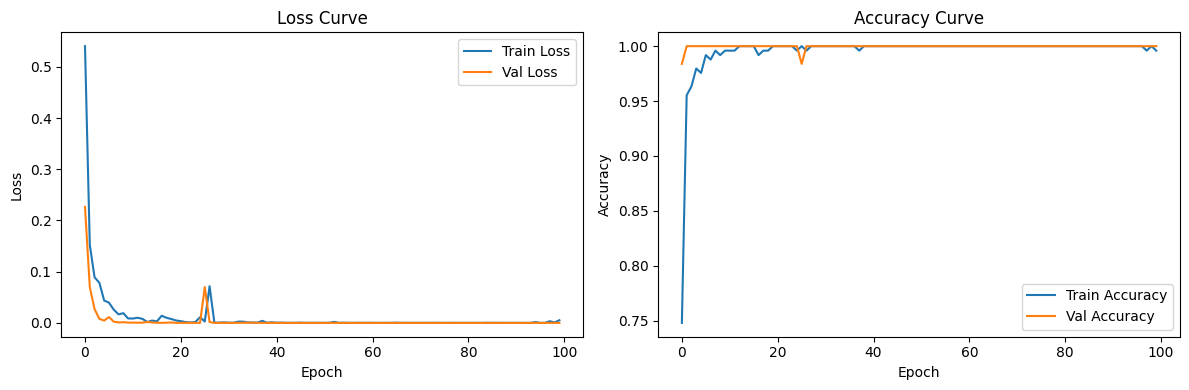

In [7]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

### Predict and evaluate

In [8]:
# Predict — keras returns probabilities, not class labels
y_proba = model.predict(X_test, verbose=0).flatten()  # flatten from (n,1) to (n,)
y_pred = (y_proba >= 0.5).astype(int)      # convert probabilities to 0/1 labels

# Performance metrics
print("=" * 50)
print("NEURAL NETWORK - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

NEURAL NETWORK - PERFORMANCE METRICS

Accuracy:  0.8163
Precision: 0.5294
Recall:    0.9000
F1-Score:  0.6667
ROC-AUC:   0.8359

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.97      0.79      0.87        39
    Died (1)       0.53      0.90      0.67        10

    accuracy                           0.82        49
   macro avg       0.75      0.85      0.77        49
weighted avg       0.88      0.82      0.83        49



### Interpretation

**ROC-AUC of 0.836** is the lowest across all models for this outcome (LR: 0.877,
RF: 0.851, XGB: 0.849), which suggests the neural network does not benefit from added
complexity on this small dataset.

Recall for deaths matches XGBoost (0.90, catching 9/10 true deaths) but precision
remains low (0.53), indicating similar false positive rates. The comparable
classification report to XGBoost despite lower AUC suggests the decision boundary
is similar but the model's probability calibration is weaker. This might be due to
neural networks being harder to calibrate on small datasets.


### Hyperparameter tuning on Death from Disease

In [9]:
def build_model(hp):
    model = keras.Sequential()

    model.add(keras.layers.Input(shape=(X_train.shape[1],)))

    # Tune number of layers
    for i in range(hp.Int('n_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Choice(f'units_{i}', [64, 128, 256, 512]),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(
            rate=hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)
        ))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Early stopping during tuning
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Tuning
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,               # reduction factor for brackets
    seed=42,
    #directory='',
    #project_name='',
    overwrite=True
)

# Run tuning
tuner.search(
    X_train, y_train,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters:")
print(f"  Number of layers: {best_hps.get('n_layers')}")
for i in range(best_hps.get('n_layers')):
    print(f"  Layer {i+1} units: {best_hps.get(f'units_{i}')}")
    print(f"  Layer {i+1} dropout: {best_hps.get(f'dropout_{i}')}")
print(f"  Learning rate: {best_hps.get('learning_rate'):.6f}")

Trial 90 Complete [00h 00m 10s]
val_loss: 3.2774455050711455e-27

Best val_loss So Far: 9.497097882359322e-37
Total elapsed time: 00h 06m 30s

Best hyperparameters:
  Number of layers: 2
  Layer 1 units: 256
  Layer 1 dropout: 0.1
  Layer 2 units: 256
  Layer 2 dropout: 0.5
  Learning rate: 0.005321


In [10]:
# Build and train best model with full epochs
best_model = tuner.hypermodel.build(best_hps)

early_stopping_final = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,           # longer patience for final training
    restore_best_weights=True
)

history = best_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping_final],
    verbose=1
)

print(f"Training stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7083 - loss: 1.0401 - val_accuracy: 0.8548 - val_loss: 0.5018
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7911 - loss: 1.2097 - val_accuracy: 0.8065 - val_loss: 1.1212
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9058 - loss: 0.8499 - val_accuracy: 1.0000 - val_loss: 4.7597e-04
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9725 - loss: 0.2363 - val_accuracy: 1.0000 - val_loss: 8.3247e-04
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9706 - loss: 0.4553 - val_accuracy: 0.9839 - val_loss: 0.0577
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9757 - loss: 0.2049 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9711 - loss: 0.0744 - val_accuracy: 0.9839 - val_loss: 0.7615
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9936 - loss: 0.7557 - val_accuracy: 0.9839 - v

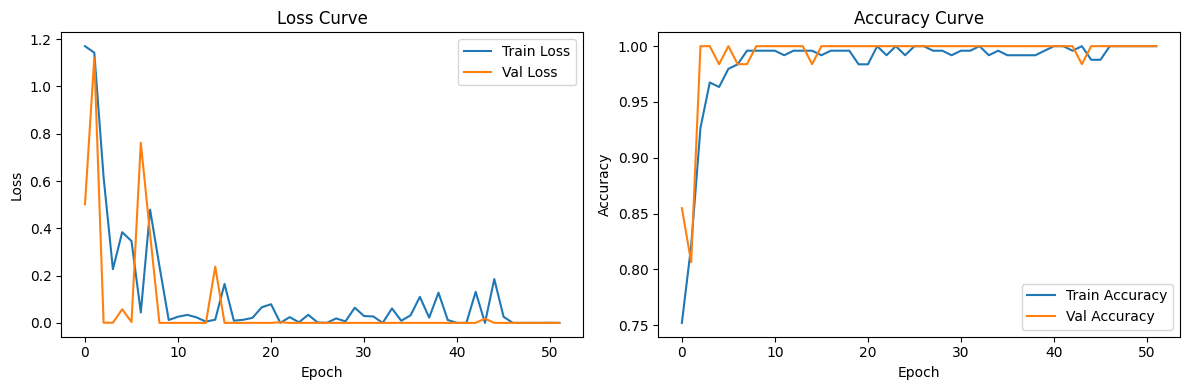

In [11]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Predict and evaluate
y_proba = best_model.predict(X_test, verbose=0).flatten()
y_pred = (y_proba >= 0.5).astype(int)

print("=" * 50)
print("NEURAL NETWORK TUNED - PERFORMANCE METRICS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

NEURAL NETWORK TUNED - PERFORMANCE METRICS

Accuracy:  0.8163
Precision: 0.5333
Recall:    0.8000
F1-Score:  0.6400
ROC-AUC:   0.8923

CLASSIFICATION REPORT
              precision    recall  f1-score   support

Survived (0)       0.94      0.82      0.88        39
    Died (1)       0.53      0.80      0.64        10

    accuracy                           0.82        49
   macro avg       0.74      0.81      0.76        49
weighted avg       0.86      0.82      0.83        49



## Train models on all outcomes

In [13]:
outcomes = ['death_from_disease', 'high_risk', 'progression', 'inss_stage']
platforms = ['rnaseq', 'microarray']

all_results = []
roc_data = {}

print("=" * 70)
print("TRAINING NEURAL NETWORK MODELS")
print("=" * 70)

for outcome in outcomes:
    print(f"\n{'=' * 70}")
    print(f"OUTCOME: {outcome.replace('_', ' ').upper()}")
    print(f"{'=' * 70}")

    roc_data[outcome] = {}

    for platform in platforms:
        print(f"\n--- {platform.upper()} ---")

        X_train, X_test, y_train, y_test = get_data(platform, outcome)

        # Detect multiclass
        n_classes = len(y_test.unique())
        is_multiclass = n_classes > 2
        average = 'weighted' if is_multiclass else 'binary'

        # Set random seeds
        random.seed(42)
        np.random.seed(42)
        tf.random.set_seed(42)

        # Scale
        sc = StandardScaler()
        X_train_scaled = sc.fit_transform(X_train)
        X_test_scaled = sc.transform(X_test)

        # SMOTE
        smote = SMOTE(random_state=42)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

        # Build model
        if is_multiclass:
            output_layer = keras.layers.Dense(n_classes, activation='softmax')
            loss = 'sparse_categorical_crossentropy'
        else:
            output_layer = keras.layers.Dense(1, activation='sigmoid')
            loss = 'binary_crossentropy'

        model = keras.Sequential([
            keras.layers.Input(shape=(X_train_resampled.shape[1],)),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dropout(0.3),
            output_layer
        ])

        model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

        # Early stopping
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        # Fit model
        model.fit(
            X_train_resampled, y_train_resampled,
            batch_size=32,
            epochs=100,
            validation_split=0.2,
            callbacks=[early_stopping],
            verbose=0  # suppress per-epoch output in loop
        )

        # Predict
        if is_multiclass:
            y_proba = model.predict(X_test_scaled, verbose=0)
            y_pred = np.argmax(y_proba, axis=1)
        else:
            y_proba = model.predict(X_test_scaled, verbose=0).flatten()
            y_pred = (y_proba >= 0.5).astype(int)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0, average=average)
        recall = recall_score(y_test, y_pred, zero_division=0, average=average)
        f1 = f1_score(y_test, y_pred, zero_division=0, average=average)

        if is_multiclass:
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        else:
            roc_auc = roc_auc_score(y_test, y_proba)

        # Store results
        all_results.append({
            'Outcome': outcome.replace('_', ' ').title(),
            'Platform': platform.upper(),
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Samples': len(y_train) + len(y_test)
        })

        # ROC curve only for binary outcomes
        if not is_multiclass:
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            roc_data[outcome][platform] = {
                'fpr': fpr,
                'tpr': tpr,
                'auc': roc_auc,
                'y_val': y_test,
                'y_proba': y_proba
            }

        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {roc_auc:.4f}")

results_df = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("SUMMARY OF ALL RESULTS")
print("=" * 70)
print(results_df.to_string(index=False))

TRAINING NEURAL NETWORK MODELS

OUTCOME: DEATH FROM DISEASE

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - Death From Disease
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 154, 1: 40}
  Test outcome distribution:  {0: 39, 1: 10}


  Accuracy:  0.7959
  Precision: 0.5000
  Recall:    0.9000
  F1-Score:  0.6429
  ROC-AUC:   0.8692

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROARRAY - Death From Disease
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {0: 155, 1: 41}
  Test outcome distribution:  {0: 40, 1: 10}
  Accuracy:  0.8000
  Precision: 0.5000
  Recall:    0.5000
  F1-Score:  0.5000
  ROC-AUC:   0.7900

OUTCOME: HIGH RISK

--- RNASEQ ---
  After QC filtering: 243 samples, 20793 genes
  HVG selected from train: 2000 genes

RNASEQ - High Risk
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {0: 130, 1: 64}
  Test outcome distribution:  {0: 33, 1: 16}
  Accuracy:  0.9388
  Precision: 0.8421
  Recall:    1.0000
  F1-Score:  0.9143
  ROC-AUC:   0.9924

--- MICROARRAY ---
  After QC filtering: 246 samples, 43291 genes
  HVG selected from train: 2000 genes

MICROAR

### Plot ROC Curves

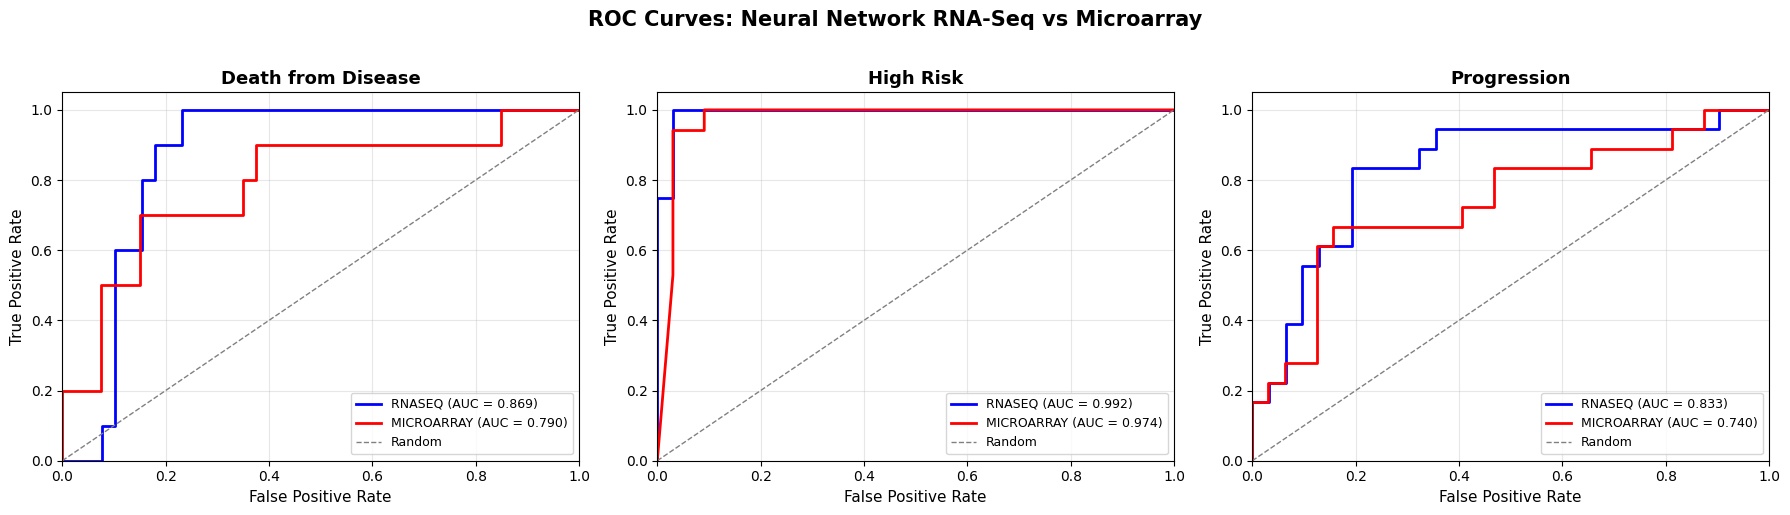

In [14]:
# Only plot binary outcomes — inss_stage is multiclass, no ROC curve
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

outcome_titles = {
    'death_from_disease': 'Death from Disease',
    'high_risk': 'High Risk',
    'progression': 'Progression'
}

colors = {
    'rnaseq': 'blue',
    'microarray': 'red'
}

for idx, outcome in enumerate(binary_outcomes):
    ax = axes[idx]

    for platform in platforms:
        # Skip if no ROC data (multiclass outcomes won't have it)
        if platform not in roc_data[outcome]:
            continue

        data = roc_data[outcome][platform]
        ax.plot(data['fpr'], data['tpr'],
                color=colors[platform],
                lw=2,
                label=f"{platform.upper()} (AUC = {data['auc']:.3f})")

    ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves: Neural Network RNA-Seq vs Microarray', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Plot Confusion matrix for INSS Stage

  After QC filtering: 243 samples, 20793 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

RNASEQ - Inss Stage
  Train samples: 194 | Test samples: 49
  Total features: 2000
  Train outcome distribution: {3: 68, 0: 48, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 17, 0: 12, 1: 8, 4: 6, 2: 6}
  After QC filtering: 246 samples, 43291 genes
  Label encoding: {'1': 0, '2': 1, '3': 2, '4': 3, '4S': 4}
  HVG selected from train: 2000 genes

MICROARRAY - Inss Stage
  Train samples: 196 | Test samples: 50
  Total features: 2000
  Train outcome distribution: {3: 71, 0: 47, 1: 32, 2: 24, 4: 22}
  Test outcome distribution:  {3: 18, 0: 12, 1: 8, 4: 6, 2: 6}


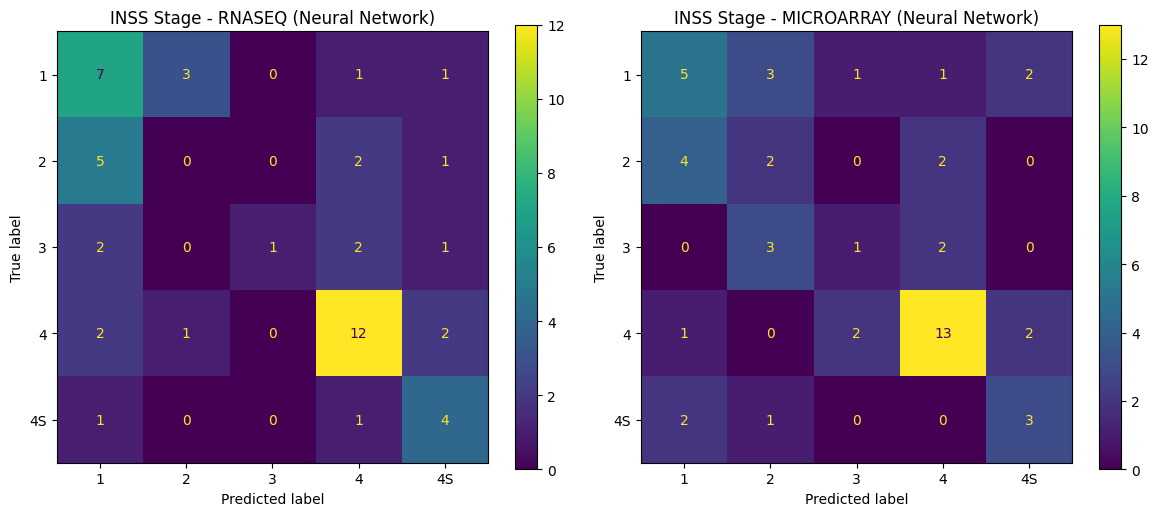

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_classes = 5
class_names = ['1', '2', '3', '4', '4S']

for idx, platform in enumerate(platforms):

    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)

    X_train, X_test, y_train, y_test = get_data(platform, 'inss_stage')

    # Scale
    sc = StandardScaler()
    X_train_scaled = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    # SMOTE
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # Build model
    model = keras.Sequential([
        keras.layers.Input(shape=(X_train_resampled.shape[1],)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(n_classes, activation='softmax')  # multiclass output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_resampled, y_train_resampled,
        batch_size=32,
        epochs=100,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=0
    )

    # Predict
    y_proba = model.predict(X_test_scaled, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'INSS Stage - {platform.upper()} (Neural Network)')

plt.tight_layout()
plt.show()

### Plot Performance metrics

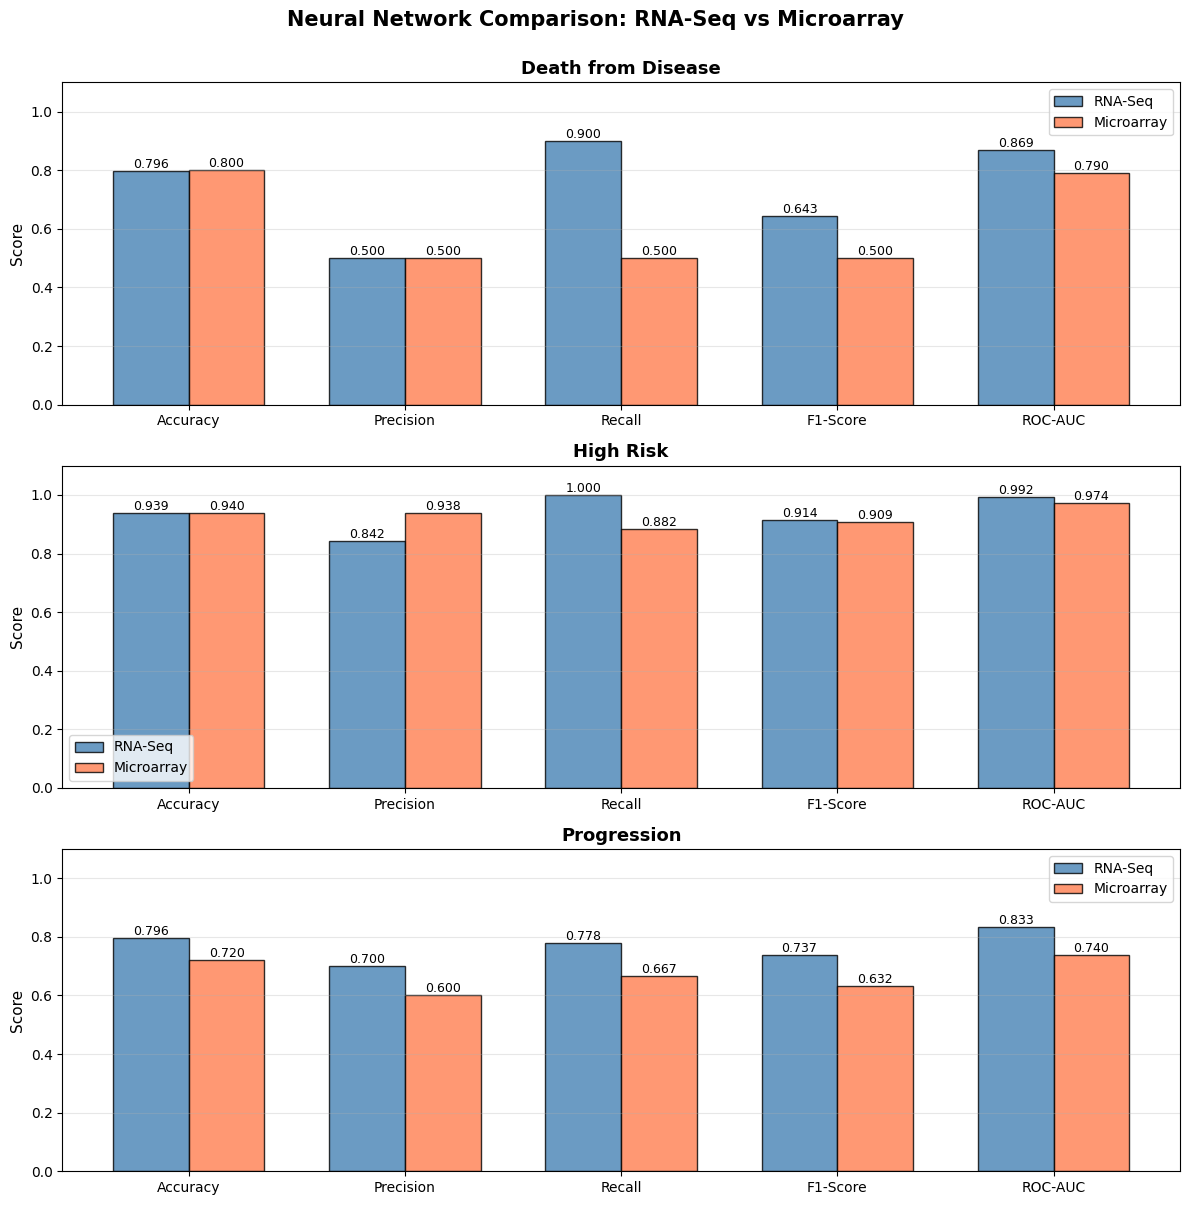

In [16]:
# Grouped Bar Chart - All Metrics
binary_outcomes = ['death_from_disease', 'high_risk', 'progression']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(len(binary_outcomes), 1, figsize=(12, 12))

for idx, outcome in enumerate(binary_outcomes):  # changed from outcomes
    ax = axes[idx]

    outcome_data = results_df[results_df['Outcome'] == outcome.replace('_', ' ').title()]

    x = np.arange(len(metrics))
    width = 0.35

    rnaseq_values = outcome_data[outcome_data['Platform'] == 'RNASEQ'][metrics].values[0]
    microarray_values = outcome_data[outcome_data['Platform'] == 'MICROARRAY'][metrics].values[0]

    bars1 = ax.bar(x - width/2, rnaseq_values, width, label='RNA-Seq',
                   color='steelblue', alpha=0.8, edgecolor='black')
    bars2 = ax.bar(x + width/2, microarray_values, width, label='Microarray',
                   color='coral', alpha=0.8, edgecolor='black')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)

    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(outcome_titles[outcome], fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.legend(fontsize=10)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Neural Network Comparison: RNA-Seq vs Microarray',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### Interpretation

### Death from Disease
RNA-Seq achieves reasonable performance (AUC: 0.869) while microarray drops significantly (AUC: 0.790),
with precision and recall both at 0.50, indicating the model is barely better than random for microarray mortality prediction. This suggests the neural network fails to generalise to microarray data for this outcome, likely due to overfitting on the small training set.

### High Risk
Strong performance on RNASEQ (AUC: 0.992) with perfect recall (1.0) — all 16 high risk cases correctly identified. Microarray performance is slightly lower (AUC: 0.974) but remains competitive with other models. High risk remains the most consistently predictable outcome across all models and platforms.

### Progression
The neural network performs comparably to LR for RNA-Seq progression (AUC: 0.833 vs 0.797) but drops for Microarray (AUC: 0.740). The stronger RNA-Seq performance suggests the network captures non-linear progression signals in RNA-Seq data that linear models miss, but struggles to replicate this on microarray.

### INSS Stage
The neural network achieves the best INSS stage accuracy across all models
(RNASEQ: 51%, MICROARRAY: 50%), with competitive AUC scores (0.783 and 0.744).
The marginal improvement over RF and XGBoost suggests neural networks may better handle the complexity of 5-class staging, though gains are modest given the small dataset size.

### Overall
The neural network shows inconsistent performance across platforms, The model is strong for RNA-Seq but notably weaker for Microarray, particularly for death from disease. This instability might be becuase the neural network models are being trained on small datasets where random weight initialisation and limited data can lead to variable outcomes. INSS stage classification is where the neural network most clearly adds value over simpler models.

In [17]:
# Save results for plotting notebook
results_df['Model'] = 'Neural Network'  # add model name
results_df.to_csv('/content/drive/MyDrive/projects/ml_module/neuroblastoma_predictive_modelling/results_nn.csv', index=False)